In [1]:
from google.colab import files
uploaded = files.upload()


Saving Fake.csv to Fake.csv
Saving True.csv to True.csv


In [2]:
import pandas as pd

df = pd.read_csv("Fake.csv")   # or your file name
df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [3]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

print(fake.shape, true.shape)

(23481, 4) (21417, 4)


In [4]:
fake["label"] = 0   # fake news
true["label"] = 1   # real news

data = pd.concat([fake, true])
data = data.sample(frac=1).reset_index(drop=True)

data.head()

,title,text,subject,date,label
0,BILL CLINTON Appears Bewildered When COAL MINE...,The difference between us and them is that we...,politics,"May 1, 2016",0
1,THE TRUE STORY OF BENGHAZI: “13 HOURS” Is Gett...,13 Hours debuted in movie theaters today. So...,Government News,"Jan 14, 2016",0
2,Syrian Air Base Trump Spent $80 Million Attac...,The Syrian air base Trump spent $80 million bo...,News,"April 7, 2017",0
3,Catalan foreign affairs chief says not plannin...,BRUSSELS (Reuters) - Catalonia s regional gove...,worldnews,"October 18, 2017",1
4,Close Trump Ally Just ADMITTED He Communicate...,"Trump s supporters, and some in the press, bel...",News,"October 12, 2016",0


In [14]:
data = data.dropna()
data["text"] = data["title"] + " " + data["text"]

In [16]:
from sklearn.model_selection import train_test_split

X = data["text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_vec, y_train)

LogisticRegression()

In [18]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9858574610244989


In [20]:
print(data["label"].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4707
           1       0.99      0.98      0.99      4273

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



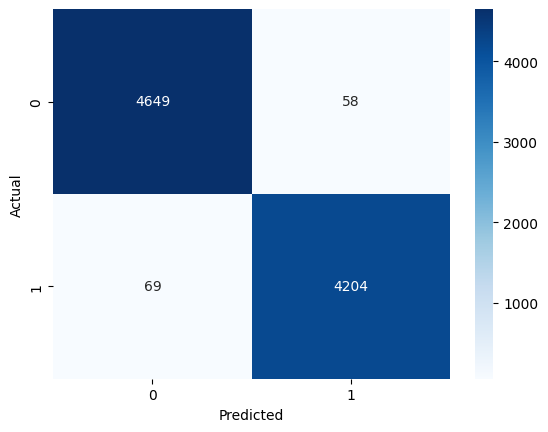

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()